# Air Pollution Prediction using CPCB Data
# Author: Ujjawal Matolia
# Goal: Predict PM2.5 using ML (XGBoost)

In [103]:
import pandas as pd
import os

folder_path = "../data/raw"

all_files = os.listdir(folder_path)

df_list = []

for file in all_files:
    if file.endswith(".csv"):
        file_path = os.path.join(folder_path, file)
        df = pd.read_csv(file_path)

        # OPTIONAL: add source file name (useful later)
        df['source_file'] = file

        df_list.append(df)

# Combine everything
combined_df = pd.concat(df_list, ignore_index=True)

print(combined_df.shape)
combined_df.head()

(4275367, 83)


,From Date,To Date,PM2.5 (ug/m3),PM10 (ug/m3),NO (ug/m3),NO2 (ug/m3),NOx (ppb),NH3 (ug/m3),SO2 (ug/m3),CO (mg/m3),...,RF (mm).6,RF (mm).7,NMHC (ug/m3),THC (),CO (ug/m3),AT (ug/m3),BP (W/mt2),AT (degree),Ozone (ppb),Gust (kl/h)
0,2010-11-01 00:00:00,2010-11-01 01:00:00,NaN,NaN,3.90,56.31,30.38,NaN,10.72,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-11-01 01:00:00,2010-11-01 02:00:00,NaN,NaN,1.96,49.81,25.75,NaN,7.95,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2010-11-01 02:00:00,2010-11-01 03:00:00,NaN,NaN,1.97,49.07,25.41,NaN,13.82,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2010-11-01 03:00:00,2010-11-01 04:00:00,NaN,NaN,5.00,53.76,29.95,NaN,21.16,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2010-11-01 04:00:00,2010-11-01 05:00:00,NaN,NaN,11.58,53.59,34.79,NaN,2.82,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [104]:
combined_df.columns

Index(['From Date', 'To Date', 'PM2.5 (ug/m3)', 'PM10 (ug/m3)', 'NO (ug/m3)',
       'NO2 (ug/m3)', 'NOx (ppb)', 'NH3 (ug/m3)', 'SO2 (ug/m3)', 'CO (mg/m3)',
       'Ozone (ug/m3)', 'Benzene (ug/m3)', 'Toluene (ug/m3)',
       'Eth-Benzene (ug/m3)', 'MP-Xylene (ug/m3)', 'O Xylene (ug/m3)',
       'Temp (degree C)', 'RH (%)', 'WS (m/s)', 'WD (deg)', 'SR (W/mt2)',
       'BP (mmHg)', 'VWS (m/s)', 'source_file', 'NOx (ug/m3)', 'WD (degree)',
       'Xylene (ug/m3)', 'AT (degree C)', 'RF (mm)', 'file_name', 'state',
       'city', 'agency', 'station_location', 'start_month', 'start_month_num',
       'start_year', 'Temp ()', 'NO ()', 'Ozone ()', 'CO2 (mg/m3)', 'NH3 ()',
       'WS (ug/m3)', 'SR (ug/m3)', 'VWS (degree)', 'Toluene ()',
       'Eth-Benzene ()', 'MP-Xylene ()', 'RH ()', 'WS ()', 'WD ()', 'SR ()',
       'BP ()', 'Xylene ()', 'AT ()', 'RF ()', 'Gust (km/hr)', 'Variance (n)',
       'Power (W)', 'WD (degree C)', 'CH4 (ug/m3)', 'BP (mmHg).1',
       'BP (mmHg).2', 'BP (mmHg).3', '

In [105]:
combined_df = pd.concat(df_list, ignore_index=True)

In [106]:
def get_city(file):
    if file.startswith("DL"):
        return "Delhi"
    elif file.startswith("MH"):
        return "Mumbai"
    elif file.startswith("KA"):
        return "Bangalore"
    elif file.startswith("TN"):
        return "Chennai"
    else:
        return "Other"

combined_df['city'] = combined_df['source_file'].apply(get_city)

In [107]:
cols = [
    'From Date',
    'PM2.5 (ug/m3)',
    'PM10 (ug/m3)',
    'NO2 (ug/m3)',
    'CO (mg/m3)',
    'city'
]

In [108]:
df = df.dropna(subset=[
    'PM2.5 (ug/m3)',
    'PM10 (ug/m3)',
    'NO2 (ug/m3)',
    'CO (mg/m3)'
])

In [109]:
df = combined_df[combined_df['city'] == 'Delhi']
df = df[cols]

In [110]:
df.head()

,From Date,PM2.5 (ug/m3),PM10 (ug/m3),NO2 (ug/m3),CO (mg/m3),city
927033,2020-11-13 14:00:00,142.70,390.00,17.92,0.83,Delhi
927034,2020-11-13 15:00:00,130.43,326.85,17.61,0.71,Delhi
927035,2020-11-13 16:00:00,114.45,274.28,24.29,0.84,Delhi
927036,2020-11-13 17:00:00,148.47,292.00,37.68,1.65,Delhi
927037,2020-11-13 18:00:00,151.22,449.30,46.61,3.24,Delhi


In [111]:
df.shape

(222281, 6)

In [112]:
df.rename(columns={
    'PM2.5 (ug/m3)': 'PM2_5',
    'PM10 (ug/m3)': 'PM10',
    'NO2 (ug/m3)': 'NO2',
    'CO (mg/m3)': 'CO',
    'From Date': 'date'
}, inplace=True)

In [113]:
df.head()

,date,PM2_5,PM10,NO2,CO,city
927033,2020-11-13 14:00:00,142.70,390.00,17.92,0.83,Delhi
927034,2020-11-13 15:00:00,130.43,326.85,17.61,0.71,Delhi
927035,2020-11-13 16:00:00,114.45,274.28,24.29,0.84,Delhi
927036,2020-11-13 17:00:00,148.47,292.00,37.68,1.65,Delhi
927037,2020-11-13 18:00:00,151.22,449.30,46.61,3.24,Delhi


In [114]:
df['date'] = pd.to_datetime(df['date'])

df['hour'] = df['date'].dt.hour
df['day'] = df['date'].dt.day
df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.dayofweek

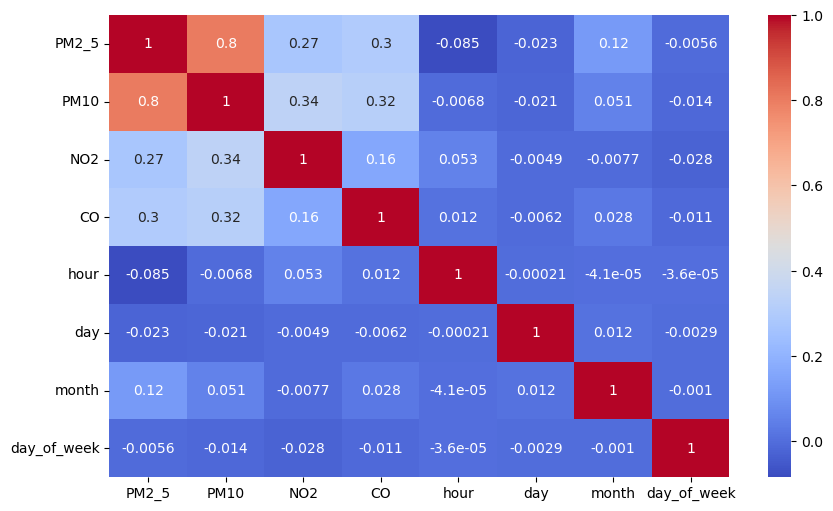

In [115]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [116]:
df = df.replace([float('inf'), -float('inf')], None)

df = df.dropna(subset=[
    'PM2_5',
    'PM10',
    'NO2',
    'CO',
    'hour',
    'month',
    'day_of_week'
])

In [117]:
df.isna().sum()

date           0
PM2_5          0
PM10           0
NO2            0
CO             0
city           0
hour           0
day            0
month          0
day_of_week    0
dtype: int64

In [118]:
X = df[['PM10', 'NO2', 'CO', 'hour', 'month', 'day_of_week']]
y = df['PM2_5']

In [119]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [120]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [121]:
from sklearn.metrics import r2_score, mean_squared_error

pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, pred))
print("MSE:", mean_squared_error(y_test, pred))

R2 Score: 0.8199857386754623
MSE: 1293.5283971072467


In [122]:
df = df.sort_values(by='date')

In [123]:
df['PM2_5_lag1'] = df['PM2_5'].shift(1)

In [124]:
df = df.dropna()

In [125]:
X = df[['PM10', 'NO2', 'CO', 'hour', 'month', 'day_of_week', 'PM2_5_lag1']]
y = df['PM2_5']

In [126]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [127]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [128]:
from sklearn.metrics import r2_score, mean_squared_error

pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, pred))
print("MSE:", mean_squared_error(y_test, pred))

R2 Score: 0.8509210362522119
MSE: 1091.443542125865


Hyper-Parameter Tuning

In [129]:
split_index = int(len(df) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

In [130]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [131]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [132]:
from sklearn.metrics import r2_score, mean_squared_error

pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, pred))
print("MSE:", mean_squared_error(y_test, pred))

R2 Score: 0.8633611143532157
MSE: 1000.366688855992


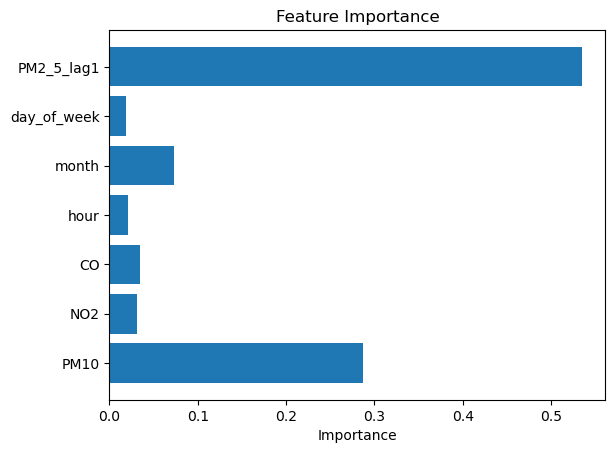

In [133]:
import matplotlib.pyplot as plt

importances = model.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.show()

In [134]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))